# 可转债每日理论价与价差追踪 V1

本 notebook 复用原项目的 `parity` 和 `crr_convertible_basic` 思路，并新增：一次性拉取转债/正股历史行情、滚动历史波动率、每日剩余期限、逐日定价及误差汇总。

V1 假设：观察期内转股价 `K` 固定为当前快照值；无风险利率 `r` 和信用利差 `spread` 为常数。结果表会用 `K_source` 明确标记这一点。

In [10]:
!pip install -U akshare

In [11]:
# 如环境尚未安装依赖，请先取消下一行注释运行
# %pip install -U akshare pandas numpy matplotlib

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import akshare as ak

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

# 一次性拉取并缓存转债一览表；后续匹配正股代码时不再重复请求。
bond_zh_cov_df = ak.bond_zh_cov()

 67%|██████▋   | 2/3 [00:06<00:03,  3.44s/it]/usr/local/lib/python3.12/dist-packages/akshare/bond/bond_zh_cov.py:342: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  big_df = pd.concat(objs=[big_df, temp_df], ignore_index=True)


## 1. 复用原来的 CRR 定价内核

函数名和主要计算逻辑与之前 notebook 保持一致；这里只增加输入校验，方便批量逐日运行时定位异常。

In [12]:
def parity(S, face, K):
    return S * face / K


def crr_convertible_basic(
    S, K, sigma, r, T, b, P_R, coupon, spread, lo, hi, t_conv, t_put,
    n, C1=130.0, C2=70.0, face=100.0, P_put=103.0, verbose=False
):
    if min(S, K, sigma, T, n) <= 0:
        raise ValueError('S、K、sigma、T、n 必须为正数')
    if hi <= lo:
        raise ValueError('hi 必须大于 lo')

    dt = T / int(n)
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    p = (np.exp((r - b) * dt) - d) / (u - d)
    if not 0 <= p <= 1:
        raise ValueError(f'CRR 风险中性概率越界：p={p:.6f}；请增加 n 或检查参数')

    interest_per_step = coupon * face * dt
    i = np.arange(int(n) + 1)
    S_terminal = S * (u ** i) * (d ** (int(n) - i))
    V = np.maximum(parity(S_terminal, face, K), P_R)

    for j in range(int(n) - 1, -1, -1):
        i = np.arange(j + 1)
        S_current = S * (u ** i) * (d ** (j - i))
        parity_current = parity(S_current, face, K)
        t_current = j * dt
        equity_weight = np.clip((parity_current - lo) / (hi - lo), 0, 1)
        discount_rate = r * equity_weight + (1 - equity_weight) * (r + spread)
        continuation = (
            np.exp(-discount_rate * dt) * (p * V[1:] + (1 - p) * V[:-1])
            + interest_per_step
        )

        if t_current >= t_conv:
            hit_call = parity_current > C1
            V = np.maximum(continuation, parity_current)
            V[hit_call] = parity_current[hit_call]
        else:
            V = continuation

        if t_current >= t_put:
            hit_put = parity_current < C2
            V[hit_put] = np.maximum(continuation[hit_put], P_put)

        if verbose:
            print(f'当前层 {j}, V 长度 {len(V)}')

    return float(V[0])

## 2. 数据与滚动波动率

波动率使用正股前复权收盘价的对数收益率：`rolling_std × sqrt(252)`。每个日期只使用截至当日的数据，不使用未来数据。

In [13]:
def _six_digit_code(code):
    match = re.search(r'(\d{6})', str(code))
    if not match:
        raise ValueError(f'无法解析六位代码：{code!r}')
    return match.group(1)


def _market_symbol(code):
    code = _six_digit_code(code)
    return ('sh' if code.startswith(('5', '6', '9')) else 'sz') + code


def _resolve_bond_metadata_from_cache(bond_code):
    """从缓存的可转债一览表中读取正股代码和当前转股价。"""
    bond_code = _six_digit_code(bond_code)
    bond_table = bond_zh_cov_df
    required = {'债券代码', '正股代码', '转股价'}
    if not required.issubset(bond_table.columns):
        raise KeyError(f'bond_zh_cov 缺少字段：{sorted(required.difference(bond_table.columns))}')
    codes = bond_table['债券代码'].astype(str).str.extract(r'(\d{6})', expand=False)
    matched = bond_table.loc[codes.eq(bond_code)]
    if matched.empty:
        raise LookupError(f'无法在缓存的 bond_zh_cov_df 中找到转债 {bond_code}')
    if len(matched) > 1:
        raise ValueError(f'转债代码 {bond_code} 匹配到多条记录，请显式传入 stock_code')
    row = matched.iloc[0]
    stock_code = _six_digit_code(row['正股代码'])
    current_k = pd.to_numeric(row['转股价'], errors='coerce')
    if not np.isfinite(current_k) or current_k <= 0:
        raise ValueError(f'转债 {bond_code} 的当前转股价无效：{row["转股价"]!r}')
    return stock_code, float(current_k)


def _standardize_daily(df, prefix):
    df = df.copy()
    aliases = {
        'date': ['date', '日期'], 'open': ['open', '开盘'],
        'high': ['high', '最高'], 'low': ['low', '最低'],
        'close': ['close', '收盘'], 'volume': ['volume', '成交量'],
    }
    rename = {}
    for standard, choices in aliases.items():
        found = next((c for c in choices if c in df.columns), None)
        if found is not None:
            rename[found] = standard if standard == 'date' else f'{prefix}_{standard}'
    df = df.rename(columns=rename)
    required = {'date', f'{prefix}_close'}
    missing = required.difference(df.columns)
    if missing:
        raise KeyError(f'{prefix} 行情缺少字段：{sorted(missing)}；实际字段：{list(df.columns)}')
    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    for col in df.columns:
        if col.startswith(prefix + '_'):
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.sort_values('date').drop_duplicates('date')


def load_daily_market_data(bond_code, stock_code, start, end, adjust='qfq'):
    start = pd.Timestamp(start).normalize()
    end = pd.Timestamp(end).normalize()
    # 为最长 252 日波动率预留约 420 个自然日，避免起始日没有 sigma。
    stock_start = start - pd.Timedelta(days=420)

    bond = ak.bond_zh_hs_cov_daily(symbol=_market_symbol(bond_code))
    bond = _standardize_daily(bond, 'bond')
    bond = bond.loc[bond['date'].between(start, end)]

    stock = ak.stock_zh_a_daily(
        symbol=_market_symbol(stock_code),
        start_date=stock_start.strftime('%Y%m%d'),
        end_date=end.strftime('%Y%m%d'),
        adjust=adjust,
    )
    stock = _standardize_daily(stock, 'stock')
    if bond.empty or stock.empty:
        raise ValueError('转债或正股行情为空，请检查代码、日期和网络连接')

    log_return = np.log(stock['stock_close'] / stock['stock_close'].shift(1))
    for window in (20, 60, 120, 252):
        stock[f'vol_{window}d'] = log_return.rolling(window, min_periods=window).std(ddof=1) * np.sqrt(252)

    # 只保留双方都有行情的交易日，避免错配节假日或停牌日期。
    daily = pd.merge(bond, stock, on='date', how='inner', validate='one_to_one')
    return daily.loc[daily['date'].between(start, end)].reset_index(drop=True)

## 3. 历史 K：未来替换常数的 `merge_asof` 示例

K 通常是分段常数。找到历次转股价调整公告后，整理一张包含“生效日”和“新转股价”的表；以下函数会把最近一个已生效的 K 向后匹配到每个交易日。V1 主函数可直接传入 `k_history` 启用，无需修改定价内核。

In [14]:
def _profile_value(profile, candidate_items):
    """从 bond_cb_profile_sina 的 item/value 表中按候选字段取值。"""
    if not {'item', 'value'}.issubset(profile.columns):
        return None
    items = profile['item'].astype(str).str.strip()
    for candidate in candidate_items:
        exact = profile.loc[items.eq(candidate), 'value']
        if not exact.empty and pd.notna(exact.iloc[0]):
            return exact.iloc[0]
    for candidate in candidate_items:
        partial = profile.loc[items.str.contains(candidate, regex=False, na=False), 'value']
        if not partial.empty and pd.notna(partial.iloc[0]):
            return partial.iloc[0]
    return None


def _first_number(value):
    if value is None or pd.isna(value):
        return None
    match = re.search(r'-?\d+(?:\.\d+)?', str(value).replace(',', ''))
    return float(match.group()) if match else None


def _infer_coupon(profile, as_of):
    """从利率说明推断 as_of 所在计息年度的票面利率。"""
    rate_raw = _profile_value(profile, ['利率说明', '票息说明', '利率条款'])
    if rate_raw is None:
        rate_raw = _profile_value(profile, ['当前利率', '票面利率', '票面年利率'])
    placeholders = {'', '--', '-', '—', 'nan', 'none', 'null', '暂无', '不适用'}
    if rate_raw is None or str(rate_raw).strip().lower() in placeholders:
        return None
    percentages = [float(x) / 100 for x in re.findall(r'(\d+(?:\.\d+)?)\s*[%％]', str(rate_raw))]
    if not percentages:
        value = _first_number(rate_raw)
        return value / 100 if value is not None else None
    if len(percentages) == 1:
        return percentages[0]
    issue_raw = _profile_value(profile, ['起息日期', '起息日', '发行日期', '发行起始日'])
    issue_date = pd.to_datetime(issue_raw, errors='coerce')
    as_of = pd.to_datetime(as_of, errors='coerce')
    if pd.isna(issue_date) or pd.isna(as_of) or as_of < issue_date:
        return None
    anniversaries_passed = as_of.year - issue_date.year
    if (as_of.month, as_of.day) < (issue_date.month, issue_date.day):
        anniversaries_passed -= 1
    coupon_year = anniversaries_passed + 1
    return percentages[min(coupon_year - 1, len(percentages) - 1)]


def load_k_history_from_akshare(bond_code):
    """读取集思录下修记录，并转换为 attach_k_series 所需格式。"""
    logs = ak.bond_cb_adj_logs_jsl(symbol=_six_digit_code(bond_code))
    required = {'下修前转股价', '下修后转股价', '新转股价生效日期'}
    if logs is None or logs.empty:
        return None
    if not required.issubset(logs.columns):
        raise KeyError(f'K 调整接口缺少字段：{sorted(required.difference(logs.columns))}')
    work = logs.copy()
    work['effective_date'] = pd.to_datetime(work['新转股价生效日期'], errors='coerce').dt.normalize()
    work['K'] = pd.to_numeric(work['下修后转股价'], errors='coerce')
    work['K_before'] = pd.to_numeric(work['下修前转股价'], errors='coerce')
    work = work.dropna(subset=['effective_date', 'K']).sort_values('effective_date')
    if work.empty:
        return None
    initial = pd.DataFrame({'effective_date': [pd.Timestamp('1900-01-01')], 'K': [work.iloc[0]['K_before']]})
    return pd.concat([initial, work[['effective_date', 'K']]], ignore_index=True).dropna(subset=['K'])


def attach_k_series(daily, current_k=None, k_history=None):
    daily = daily.sort_values('date').copy()
    if k_history is None:
        if current_k is None or float(current_k) <= 0:
            raise ValueError('使用常数 K 时必须提供正数 current_k')
        daily['K'] = float(current_k)
        daily['K_source'] = 'current_snapshot_constant'
        return daily

    # 公告整理示例：日期必须使用“调整后转股价生效日”，不是公告发布日期。
    # k_history = pd.DataFrame({
    #     'effective_date': ['2023-01-01', '2024-06-20', '2025-05-30'],
    #     'K': [20.00, 19.82, 15.50],
    # })
    # daily_with_k = attach_k_series(daily, k_history=k_history)
    changes = k_history.copy()
    required = {'effective_date', 'K'}
    if not required.issubset(changes.columns):
        raise KeyError(f'k_history 必须包含字段：{sorted(required)}')
    changes['effective_date'] = pd.to_datetime(changes['effective_date']).dt.normalize()
    changes['K'] = pd.to_numeric(changes['K'], errors='raise')
    changes = changes.sort_values('effective_date').drop_duplicates('effective_date', keep='last')

    # backward 表示每个交易日只能看到当日或之前已经生效的最新 K，避免未来数据泄漏。
    daily = pd.merge_asof(
        daily, changes, left_on='date', right_on='effective_date', direction='backward'
    )
    if daily['K'].isna().any():
        first_missing = daily.loc[daily['K'].isna(), 'date'].min().date()
        raise ValueError(f'K 调整历史未覆盖最早估值日 {first_missing}；请补充初始转股价及其生效日')
    if (daily['K'] <= 0).any():
        raise ValueError('k_history 中存在非正转股价')
    daily['K_source'] = 'historical_effective_date_merge_asof'
    return daily

## 4. 逐日估值、每日价差表与汇总

In [15]:
def build_daily_tracking_table(
    bond_code, stock_code=None, start=None, end=None, maturity_date=None,
    *, k_history=None, auto_k_history=True, vol_window=60, r=0.02, b=0.0, spread=0.01,
    coupon=None, P_R=108.0, lo=70.0, hi=130.0, t_conv=0.0, t_put=None,
    n=200, C1=130.0, C2=70.0, face=100.0, P_put=103.0, adjust='qfq'
):
    if start is None or end is None:
        raise ValueError('必须提供 start 和 end')
    if vol_window not in (20, 60, 120, 252):
        raise ValueError('vol_window 目前支持 20、60、120、252')
    cached_stock_code, current_k = _resolve_bond_metadata_from_cache(bond_code)
    if stock_code is None:
        stock_code = cached_stock_code
    profile = None
    if maturity_date is None:
        profile = ak.bond_cb_profile_sina(symbol=_market_symbol(bond_code))
        maturity_raw = _profile_value(profile, ['到期日', '到期日期', '债券到期日'])
        maturity = pd.to_datetime(maturity_raw, errors='coerce')
        if pd.isna(maturity):
            raise ValueError(f'无法从转债资料解析到期日，原始值：{maturity_raw!r}')
        maturity = maturity.normalize()
    else:
        maturity = pd.Timestamp(maturity_date).normalize()
    if t_put is None:
        if profile is None:
            profile = ak.bond_cb_profile_sina(symbol=_market_symbol(bond_code))
        put_start_raw = _profile_value(
            profile, ['回售起始日', '回售开始日', '回售期起始日', '有条件回售起始日']
        )
        put_start = pd.to_datetime(put_start_raw, errors='coerce')
        if pd.notna(put_start) and put_start.normalize() <= maturity:
            put_start = put_start.normalize()
            put_source = 'akshare_profile_put_start_date'
        else:
            put_start = maturity - pd.DateOffset(years=2)
            put_source = 'inferred_last_two_years_before_maturity'
            warnings.warn(
                f'转债资料未提供可解析的回售起始日，按到期前两年 {put_start.date()} 推定；'
                '该日期需结合募集说明书核对'
            )
    else:
        put_start = pd.NaT
        put_source = 'manual_t_put_override'
    daily = load_daily_market_data(bond_code, stock_code, start, end, adjust=adjust)
    if k_history is not None:
        k_source = 'manual_history'
        k_validation_status = 'manual_history'
    elif auto_k_history:
        k_source = 'current_snapshot_constant'
        k_validation_status = 'no_history_current_constant'
        try:
            candidate_history = load_k_history_from_akshare(bond_code)
            if candidate_history is not None:
                last_history_k = float(candidate_history.sort_values('effective_date').iloc[-1]['K'])
                if np.isclose(last_history_k, current_k, rtol=0.0, atol=0.011):
                    k_history = candidate_history
                    k_source = 'akshare_bond_cb_adj_logs_jsl'
                    k_validation_status = 'history_reconciled'
                else:
                    k_source = 'current_snapshot_fallback_incomplete_history'
                    k_validation_status = 'history_mismatch_current_fallback'
                    warnings.warn(
                        f'K 调整历史末值 {last_history_k:.4f} 与当前快照 {current_k:.4f} 不一致；'
                        '可能遗漏分红等调整，回退到缓存的当前转股价'
                    )
        except Exception as exc:
            k_source = 'current_snapshot_fallback_history_error'
            k_validation_status = 'history_error_current_fallback'
            warnings.warn(f'自动读取 K 调整记录失败，回退到缓存的当前转股价：{type(exc).__name__}: {exc}')
    else:
        k_source = 'current_snapshot_constant'
        k_validation_status = 'auto_history_disabled'
    daily = attach_k_series(daily, current_k=current_k, k_history=k_history)
    daily['K_source'] = k_source
    daily['K_validation_status'] = k_validation_status
    if coupon is None:
        if profile is None:
            profile = ak.bond_cb_profile_sina(symbol=_market_symbol(bond_code))
        daily['coupon_used'] = daily['date'].map(lambda date: _infer_coupon(profile, date))
        daily['coupon_source'] = 'akshare_profile_inferred_by_accrual_year'
        if daily['coupon_used'].isna().any():
            raise ValueError('无法从转债资料推断部分日期的 coupon；请显式传入 coupon=')
    else:
        daily['coupon_used'] = float(coupon)
        daily['coupon_source'] = 'manual_override_constant'
    daily['T'] = (maturity - daily['date']).dt.days / 365.0
    daily = daily.loc[daily['T'] > 0].copy()
    if t_put is None:
        daily['put_start_date'] = put_start
        daily['t_put_used'] = ((put_start - daily['date']).dt.days / 365.0).clip(lower=0.0)
        daily['put_status'] = np.where(
            daily['date'] >= put_start, 'in_put_period', 'not_yet_in_put_period'
        )
    else:
        daily['put_start_date'] = pd.NaT
        daily['t_put_used'] = float(t_put)
        daily['put_status'] = 'manual_t_put_override'
    daily['put_source'] = put_source
    daily['sigma_used'] = daily[f'vol_{vol_window}d']
    daily['parity'] = parity(daily['stock_close'], face, daily['K'])
    daily['premium_rate'] = daily['bond_close'] / daily['parity'] - 1

    model_prices, no_call_prices, errors = [], [], []
    for row in daily.itertuples(index=False):
        if not np.isfinite(row.sigma_used) or row.sigma_used <= 0:
            model_prices.append(np.nan)
            no_call_prices.append(np.nan)
            errors.append('insufficient_volatility_history')
            continue
        try:
            price = crr_convertible_basic(
                S=row.stock_close, K=row.K, sigma=row.sigma_used, r=r, T=row.T, b=b,
                P_R=P_R, coupon=row.coupon_used, spread=spread, lo=lo, hi=hi,
                t_conv=t_conv, t_put=row.t_put_used, n=n, C1=C1, C2=C2,
                face=face, P_put=P_put,
            )
            price_no_call = crr_convertible_basic(
                S=row.stock_close, K=row.K, sigma=row.sigma_used, r=r, T=row.T, b=b,
                P_R=P_R, coupon=row.coupon_used, spread=spread, lo=lo, hi=hi,
                t_conv=t_conv, t_put=row.t_put_used, n=n, C1=np.inf, C2=C2,
                face=face, P_put=P_put,
            )
            model_prices.append(price)
            no_call_prices.append(price_no_call)
            errors.append('')
        except Exception as exc:
            model_prices.append(np.nan)
            no_call_prices.append(np.nan)
            errors.append(f'{type(exc).__name__}: {exc}')

    daily['theoretical_price'] = model_prices
    daily['theoretical_price_no_call'] = no_call_prices
    daily['call_impact'] = daily['theoretical_price_no_call'] - daily['theoretical_price']
    daily['pricing_error'] = errors
    daily['gap'] = daily['theoretical_price'] - daily['bond_close']
    daily['gap_pct'] = daily['gap'] / daily['bond_close']
    daily['abs_gap'] = daily['gap'].abs()
    daily['abs_gap_pct'] = daily['gap_pct'].abs()
    daily['market_change'] = daily['bond_close'].diff()
    daily['model_change'] = daily['theoretical_price'].diff()
    daily['rolling_20d_mean_gap_pct'] = daily['gap_pct'].rolling(20).mean()
    daily['rolling_20d_mape'] = daily['abs_gap_pct'].rolling(20).mean()

    preferred = [
        'date', 'bond_close', 'stock_close', 'K', 'K_source', 'K_validation_status',
        'coupon_used', 'coupon_source',
        'parity', 'premium_rate',
        'T', 'put_start_date', 't_put_used', 'put_status', 'put_source',
        'vol_20d', 'vol_60d', 'vol_120d', 'vol_252d', 'sigma_used',
        'theoretical_price', 'theoretical_price_no_call', 'call_impact',
        'gap', 'gap_pct', 'abs_gap', 'abs_gap_pct',
        'market_change', 'model_change', 'rolling_20d_mean_gap_pct',
        'rolling_20d_mape', 'pricing_error',
    ]
    return daily[[c for c in preferred if c in daily.columns]].reset_index(drop=True)


def summarize_tracking_error(daily):
    valid = daily.dropna(subset=['gap', 'gap_pct'])
    if valid.empty:
        raise ValueError('没有可汇总的有效定价结果，请检查 sigma 和 pricing_error')
    return pd.Series({
        '有效交易日': len(valid),
        '平均价差': valid['gap'].mean(),
        '平均相对价差': valid['gap_pct'].mean(),
        'MAE': valid['abs_gap'].mean(),
        'MAPE': valid['abs_gap_pct'].mean(),
        'RMSE': np.sqrt(np.mean(valid['gap'] ** 2)),
        '相对价差中位数': valid['gap_pct'].median(),
        '相对价差标准差': valid['gap_pct'].std(ddof=1),
        '相对价差5%分位': valid['gap_pct'].quantile(0.05),
        '相对价差95%分位': valid['gap_pct'].quantile(0.95),
        '平均强赎影响': valid['call_impact'].mean() if 'call_impact' in valid else np.nan,
    })


def plot_tracking_table(daily):
    valid = daily.dropna(subset=['theoretical_price']).copy()
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    axes[0].plot(valid['date'], valid['bond_close'], label='Market bond close')
    axes[0].plot(valid['date'], valid['theoretical_price'], label='CRR theoretical price')
    if 'theoretical_price_no_call' in valid:
        axes[0].plot(valid['date'], valid['theoretical_price_no_call'], '--', label='CRR without call cutoff')
    axes[0].set_ylabel('Price')
    axes[0].legend()
    axes[0].grid(alpha=0.25)
    axes[1].plot(valid['date'], valid['gap_pct'] * 100, label='Daily gap %')
    axes[1].plot(valid['date'], valid['rolling_20d_mean_gap_pct'] * 100, label='20D mean gap %')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_ylabel('Gap (%)')
    axes[1].legend()
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    return fig, axes

## 5. 运行示例

下面是逐日追踪示例。正股代码、当前转股价、到期日和 coupon 会自动读取；`t_put=None` 时优先读取回售起始日，资料缺失则按到期前两年推定并发出提示。首次运行需要联网访问 AKShare 数据源。

,date,bond_close,stock_close,K,K_source,coupon_used,coupon_source,parity,premium_rate,T,vol_20d,vol_60d,vol_120d,vol_252d,sigma_used,theoretical_price,theoretical_price_no_call,call_impact,gap,gap_pct,abs_gap,abs_gap_pct,market_change,model_change,rolling_20d_mean_gap_pct,rolling_20d_mape,pricing_error
223,2026-06-24 00:00:00,112.75,15.63,40.00,akshare_bond_cb_adj_logs_jsl,2.00%,akshare_profile_inferred_by_accrual_year,39.08,188.54%,0.9973,26.32%,29.48%,25.25%,24.07%,29.48%,108.72,108.72,0.00,-4.02,-3.57%,4.022238,3.57%,-1.072000,0.003115,-6.65%,6.65%,
224,2026-06-25 00:00:00,112.51,15.50,40.00,akshare_bond_cb_adj_logs_jsl,2.00%,akshare_profile_inferred_by_accrual_year,38.75,190.35%,0.9945,26.24%,29.41%,25.26%,24.07%,29.41%,108.73,108.73,0.00,-3.78,-3.36%,3.784058,3.36%,-0.235000,0.003180,-6.51%,6.51%,
225,2026-06-26 00:00:00,112.04,15.04,40.00,akshare_bond_cb_adj_logs_jsl,2.00%,akshare_profile_inferred_by_accrual_year,37.60,197.98%,0.9918,27.44%,29.80%,25.55%,24.24%,29.80%,108.73,108.73,0.00,-3.31,-2.95%,3.309936,2.95%,-0.471000,0.003121,-6.35%,6.35%,
226,2026-06-29 00:00:00,112.39,15.73,40.00,akshare_bond_cb_adj_logs_jsl,2.00%,akshare_profile_inferred_by_accrual_year,39.33,185.79%,0.9836,32.03%,31.29%,26.35%,24.57%,31.29%,108.74,108.74,0.00,-3.64,-3.24%,3.643020,3.24%,0.346000,0.012916,-6.19%,6.19%,
227,2026-06-30 00:00:00,111.99,15.40,40.00,akshare_bond_cb_adj_logs_jsl,2.00%,akshare_profile_inferred_by_accrual_year,38.50,190.88%,0.9808,29.17%,31.54%,26.40%,24.64%,31.54%,108.75,108.75,0.00,-3.24,-2.90%,3.243205,2.90%,-0.397000,0.002815,-5.94%,5.94%,
228,2026-07-01 00:00:00,113.01,16.04,40.00,akshare_bond_cb_adj_logs_jsl,2.00%,akshare_profile_inferred_by_accrual_year,40.10,181.82%,0.9781,34.02%,32.61%,27.11%,24.97%,32.61%,108.75,108.75,0.00,-4.25,-3.76%,4.253654,3.76%,1.018000,0.007550,-5.74%,5.74%,
229,2026-07-02 00:00:00,113.06,16.21,40.00,akshare_bond_cb_adj_logs_jsl,2.00%,akshare_profile_inferred_by_accrual_year,40.52,178.98%,0.9753,33.94%,32.67%,27.16%,24.97%,32.67%,108.76,108.76,0.00,-4.30,-3.80%,4.296213,3.80%,0.047000,0.004441,-5.53%,5.53%,
230,2026-07-03 00:00:00,113.85,16.64,40.00,akshare_bond_cb_adj_logs_jsl,2.00%,akshare_profile_inferred_by_accrual_year,41.60,173.68%,0.9726,34.46%,32.65%,27.45%,25.12%,32.65%,108.76,108.77,0.00,-5.09,-4.47%,5.085097,4.47%,0.795000,0.006116,-5.38%,5.38%,
231,2026-07-06 00:00:00,114.23,16.67,40.00,akshare_bond_cb_adj_logs_jsl,2.00%,akshare_profile_inferred_by_accrual_year,41.68,174.10%,0.9644,34.49%,32.65%,27.42%,25.10%,32.65%,108.78,108.78,0.00,-5.45,-4.78%,5.454993,4.78%,0.380000,0.010104,-5.22%,5.22%,
232,2026-07-07 00:00:00,114.20,16.21,40.00,akshare_bond_cb_adj_logs_jsl,2.00%,akshare_profile_inferred_by_accrual_year,40.52,181.81%,0.9616,34.58%,32.51%,27.35%,25.24%,32.51%,108.78,108.78,0.00,-5.43,-4.75%,5.427989,4.75%,-0.027000,0.000005,-5.07%,5.07%,


,0
有效交易日,243.000000
平均价差,-11.425148
平均相对价差,-0.095116
MAE,11.425148
MAPE,0.095116
RMSE,11.801386
相对价差中位数,-0.098409
相对价差标准差,0.022765
相对价差5%分位,-0.133579
相对价差95%分位,-0.049030


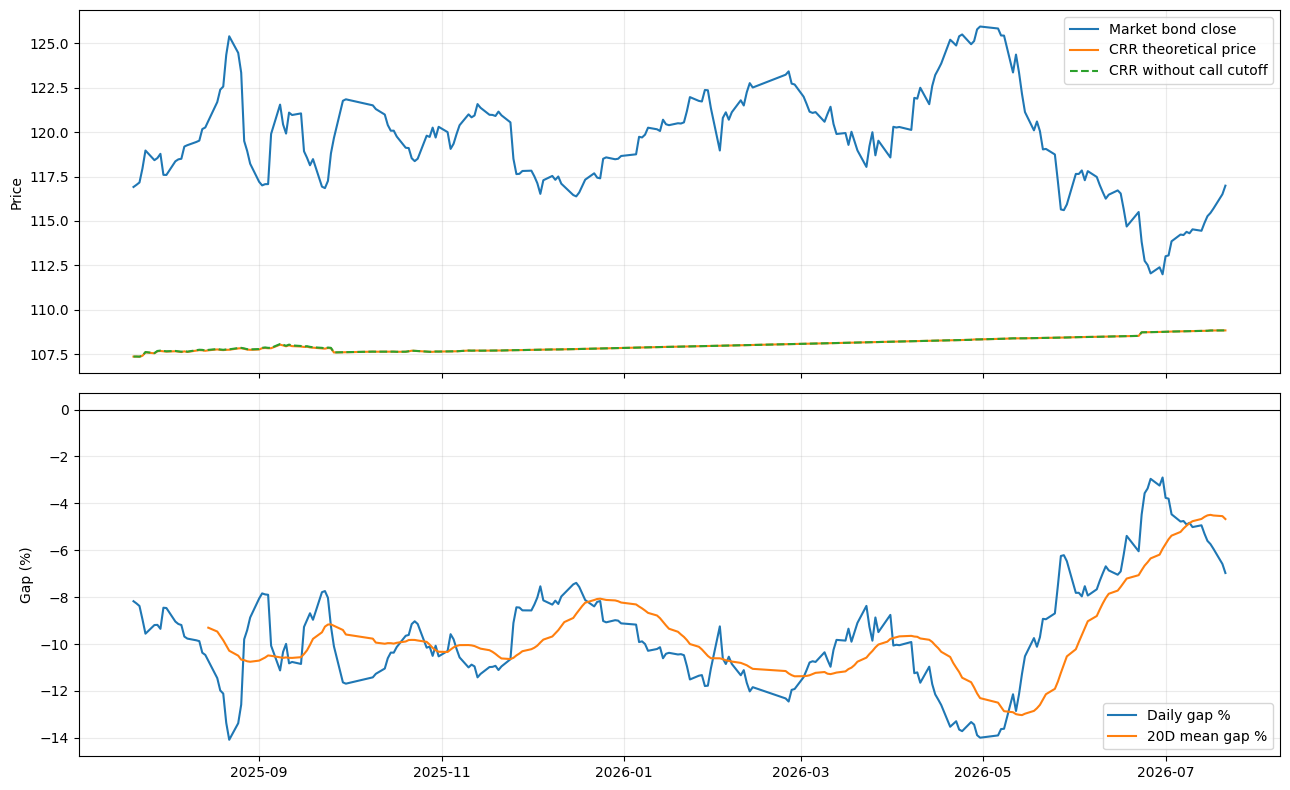

In [19]:
daily_table = build_daily_tracking_table(
    bond_code='123117',
    start='2025-07-21',
    end='2026-07-21',
    vol_window=60,
    P_R=110.0,
    r=0.02,
    spread=0.01,
    n=200,
)

display(daily_table.tail(20).style.format({
    'bond_close': '{:.2f}', 'stock_close': '{:.2f}', 'K': '{:.2f}',
    'parity': '{:.2f}', 'premium_rate': '{:.2%}', 'T': '{:.4f}', 't_put_used': '{:.4f}',
    'coupon_used': '{:.2%}', 'theoretical_price_no_call': '{:.2f}',
    'call_impact': '{:.2f}',
    'vol_20d': '{:.2%}', 'vol_60d': '{:.2%}', 'vol_120d': '{:.2%}',
    'vol_252d': '{:.2%}', 'sigma_used': '{:.2%}',
    'theoretical_price': '{:.2f}', 'gap': '{:.2f}', 'gap_pct': '{:.2%}',
    'abs_gap_pct': '{:.2%}', 'rolling_20d_mean_gap_pct': '{:.2%}',
    'rolling_20d_mape': '{:.2%}',
}))
display(summarize_tracking_error(daily_table))
plot_tracking_table(daily_table)

### 导出（可选）

取消注释即可保存完整每日波动表。

In [17]:
# daily_table.to_csv('daily_tracking_123257.csv', index=False, encoding='utf-8-sig')
# daily_table.to_excel('daily_tracking_123257.xlsx', index=False)

In [20]:
# 1. 转债市价：describe() + 价格范围
market_desc = daily_table["bond_close"].dropna().describe()
print("转债市价 describe()：")
print(market_desc)
print(f"范围：{market_desc['min']:.2f} ~ {market_desc['max']:.2f}")
print(f"均值：{market_desc['mean']:.2f}")


# 2. 实际用于定价的 σ 序列
sigma_desc = daily_table["sigma_used"].dropna().describe()
print("\nσ 序列 describe()：")
print(sigma_desc)
print(f"均值：{sigma_desc['mean']:.4f}（{sigma_desc['mean']:.2%}）")
print(f"最小值：{sigma_desc['min']:.4f}（{sigma_desc['min']:.2%}）")
print(f"最大值：{sigma_desc['max']:.4f}（{sigma_desc['max']:.2%}）")


# 3. 随机挑选一个五项数据都有效的交易日
cols = [
    "date",
    "stock_close",
    "sigma_used",
    "T",
    "theoretical_price",
    "bond_close",
]

one_day = daily_table.dropna(subset=cols).sample(
    n=1,
    random_state=42,   # 删除此参数即可每次随机挑不同日期
).iloc[0]

print("\n抽样日：", one_day["date"].strftime("%Y-%m-%d"))
print(f"S_t：     {one_day['stock_close']:.2f}")
print(f"sigma_t： {one_day['sigma_used']:.4f}（{one_day['sigma_used']:.2%}）")
print(f"T_t：     {one_day['T']:.4f} 年")
print(f"模型价：  {one_day['theoretical_price']:.2f}")
print(f"市价：    {one_day['bond_close']:.2f}")

转债市价 describe()：
count    243.000000
mean     119.448284
std        2.842801
min      111.990000
25%      117.520500
50%      119.695000
75%      121.124000
max      125.950000
Name: bond_close, dtype: float64
范围：111.99 ~ 125.95
均值：119.45

σ 序列 describe()：
count    243.000000
mean       0.236565
std        0.044591
min        0.162945
25%        0.198279
50%        0.232500
75%        0.275108
max        0.340881
Name: sigma_used, dtype: float64
均值：0.2366（23.66%）
最小值：0.1629（16.29%）
最大值：0.3409（34.09%）

抽样日： 2025-08-22
S_t：     23.06
sigma_t： 0.2508（25.08%）
T_t：     1.8356 年
模型价：  107.74
市价：    125.40


Precise not accurate，依旧低估市场